## Multi Head Attention

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
batch_size = 32
sequence_length = 10
d_model = 64
num_heads = 8

In [3]:
x = np.random.rand(batch_size, sequence_length, d_model)
weights = np.random.rand(d_model, d_model)
out = np.matmul(x, weights)
print(out.shape)

(32, 10, 64)


In [4]:
print(x)

[[[0.92067726 0.20187039 0.72068011 ... 0.56946194 0.8945424  0.62947853]
  [0.24059574 0.69727719 0.01600752 ... 0.34816232 0.8965538  0.04757997]
  [0.22372981 0.18305018 0.4977452  ... 0.10383393 0.61000619 0.64842544]
  ...
  [0.21191441 0.35483285 0.45981039 ... 0.68994439 0.31319057 0.54640023]
  [0.72534245 0.16829541 0.63456643 ... 0.55510329 0.13598746 0.06594148]
  [0.80335979 0.69190727 0.94839246 ... 0.08202169 0.90759857 0.6657552 ]]

 [[0.0947976  0.68965168 0.8899143  ... 0.70203654 0.20576416 0.42825439]
  [0.48446837 0.83056213 0.55042673 ... 0.59582596 0.7670061  0.96146284]
  [0.95052059 0.01013365 0.24958965 ... 0.80666695 0.85248096 0.26289313]
  ...
  [0.25135642 0.05745011 0.61667083 ... 0.43494537 0.00426222 0.98849955]
  [0.22548163 0.79073182 0.76720214 ... 0.89860501 0.45180499 0.57918156]
  [0.98779683 0.78408874 0.64081058 ... 0.60526111 0.70457921 0.27357558]]

 [[0.41661374 0.14935881 0.6719452  ... 0.51120887 0.56385798 0.01734777]
  [0.53844013 0.645055

In [6]:
qkv_layer = lambda x: np.random.rand(*x.shape[:-1], 3 * d_model)
qkv = qkv_layer(x)
qkv.shape

(32, 10, 192)

<function matplotlib.pyplot.show(close=None, block=None)>

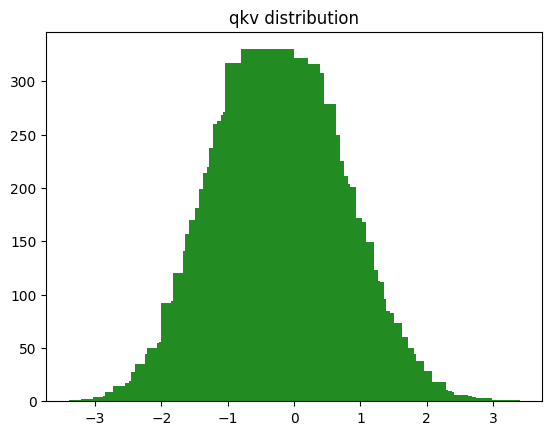

In [7]:
out = np.matmul(x, weights)
y_val = np.histogram(out.flatten(), bins=200)[0]
x_val = np.linspace(-3, 3, 200)
plt.bar(x_val, y_val, align='center', color=['forestgreen'])
plt.title('qkv distribution')
plt.show

In [8]:
print(out)

[[[22.70021339 16.50678619 18.56620215 ... 18.87667144 16.69376686
   18.53401253]
  [19.07457349 14.24972751 14.73833981 ... 15.71418384 12.97890998
   14.18722697]
  [16.48963175 13.54317843 14.38986323 ... 15.04489231 12.87645781
   13.64203352]
  ...
  [18.3886958  15.13196854 15.70196632 ... 17.66551852 14.83078308
   14.71997847]
  [19.25810743 15.98978787 16.67826094 ... 16.72601505 13.59044513
   14.94191539]
  [18.16420992 14.71408899 17.62227398 ... 16.51150191 14.6289083
   14.88232689]]

 [[17.40258852 13.84939147 14.9958762  ... 16.75873724 14.34576558
   14.30516774]
  [15.34383962 13.34937091 14.92218251 ... 13.96283168 11.60062137
   13.08508056]
  [16.51545098 14.31406021 14.65002053 ... 15.89664227 13.14707582
   13.26059133]
  ...
  [19.30386068 15.44332723 16.67378832 ... 15.85717909 14.23510767
   14.56125343]
  [19.05887021 16.15123118 17.47692542 ... 18.13462258 15.62497325
   15.47352581]
  [19.78511382 16.42651347 17.38450606 ... 17.94944628 15.26554042
   16.3

In [10]:
head_dim = d_model // num_heads
qkv = qkv.reshape(batch_size, sequence_length, num_heads, 3 * head_dim)
qkv.shape

(32, 10, 8, 24)

In [11]:
qkv = np.transpose(qkv, axes=(0, 2, 1, 3)) # [batch_size, num_heads, sequence_length, 3*head_dim]
qkv.shape

(32, 8, 10, 24)

In [12]:
q, k, v = np.split(qkv, 3, axis=-1)
q.shape, k.shape, v.shape

((32, 8, 10, 8), (32, 8, 10, 8), (32, 8, 10, 8))

## Self Attention for multiple heads

For a single head:
$$
\text{self attention} = softmax\bigg(\frac{Q.K^T}{\sqrt{d_k}}+M\bigg)
$$

$$
\text{new V} = \text{self attention}.V
$$ 

In [14]:
d_k = q.shape[-1]
scaled = np.matmul(q, np.swapaxes(k, -1, -2)) / math.sqrt(d_k)
scaled.shape

(32, 8, 10, 10)

In [15]:
k.T.shape

(8, 10, 8, 32)

In [16]:
y = np.random.randn(2, 3)

In [17]:
y_transposed = np.transpose(y, axes=(1, 0))
y_transposed

array([[-1.21888839, -0.13807243],
       [-1.5406992 , -0.30135535],
       [-1.09536742,  0.76580746]])

In [18]:
y_transposed = np.transpose(y, axes=(1, 0))
y_transposed

array([[-1.21888839, -0.13807243],
       [-1.5406992 , -0.30135535],
       [-1.09536742,  0.76580746]])

In [19]:
np.swapaxes(k, -1, -2) == np.swapaxes(k, -2, -1)

array([[[[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True]],

        [[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True]],

        [[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  T

In [20]:
mask = np.full(scaled.shape, float('-inf'))
mask = np.triu(mask, k=1)
mask[0, 1] # mask for input to a single head

array([[  0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
       [  0.,   0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
       [  0.,   0.,   0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
       [  0.,   0.,   0.,   0., -inf, -inf, -inf, -inf, -inf, -inf],
       [  0.,   0.,   0.,   0.,   0., -inf, -inf, -inf, -inf, -inf],
       [  0.,   0.,   0.,   0.,   0.,   0., -inf, -inf, -inf, -inf],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0., -inf, -inf, -inf],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., -inf, -inf],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., -inf],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]])

In [21]:
(scaled + mask)[0][0]

array([[0.68165727,       -inf,       -inf,       -inf,       -inf,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [0.64390421, 0.68198837,       -inf,       -inf,       -inf,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [0.81576155, 0.74700591, 0.89457437,       -inf,       -inf,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [0.64001728, 0.66512302, 0.87013524, 0.58189257,       -inf,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [0.5612559 , 0.55725268, 0.75042389, 0.41026757, 0.81902058,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [0.70163017, 0.64598099, 0.78452264, 0.52207053, 0.83203803,
        0.65619537,       -inf,       -inf,       -inf,       -inf],
       [0.74767929, 0.74539622, 1.00575418, 0.60925029, 1.08716147,
        0.84257697, 0.69444525,       -inf,       -inf,       -inf],
       [0.66590289, 0.67167287, 0.8820152

In [22]:
scaled += mask

In [23]:
np.exp(0.5596) / (np.exp(0.5596) + np.exp(0.0404))

np.float64(0.6269606805367254)

In [24]:
attention = np.exp(scaled) / np.sum(np.exp(scaled), axis=-1, keepdims=True)
attention.shape

(32, 8, 10, 10)

In [25]:
attention[0][0]

array([[1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.49048011, 0.50951989, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.33161374, 0.3095796 , 0.35880666, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.23653499, 0.24254855, 0.29773806, 0.2231784 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.1866319 , 0.18588627, 0.22549686, 0.16047689, 0.24150808,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.1677062 , 0.15862841, 0.1822002 , 0.14014169, 0.19106649,
        0.16025701, 0.        , 0.        , 0.        , 0.        ],
       [0.13132313, 0.13102365, 0.16998935, 0.11434634, 0.18440659,
        0.14439586, 0.12451508, 0.        , 0.        , 0.        ],
       [0.11289606, 0.11354935, 0.1401313

In [26]:
values = np.matmul(attention, v)
values.shape

(32, 8, 10, 8)

In [27]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.shape[-1]
    scaled = np.matmul(q, np.swapaxes(k, -1, -2)) / math.sqrt(d_k)
    if mask is not None:
        scaled += mask
    attention = np.exp(scaled) / np.sum(np.exp(scaled), axis=-1, keepdims=True)
    values = np.matmul(attention, v)
    return values, attention

In [28]:
values, attention = scaled_dot_product(q, k, v, mask=mask)
attention.shape

(32, 8, 10, 10)

In [29]:
attention[0][0]

array([[1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.49048011, 0.50951989, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.33161374, 0.3095796 , 0.35880666, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.23653499, 0.24254855, 0.29773806, 0.2231784 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.1866319 , 0.18588627, 0.22549686, 0.16047689, 0.24150808,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.1677062 , 0.15862841, 0.1822002 , 0.14014169, 0.19106649,
        0.16025701, 0.        , 0.        , 0.        , 0.        ],
       [0.13132313, 0.13102365, 0.16998935, 0.11434634, 0.18440659,
        0.14439586, 0.12451508, 0.        , 0.        , 0.        ],
       [0.11289606, 0.11354935, 0.1401313

In [30]:
values.shape

(32, 8, 10, 8)

In [31]:
values = values.reshape(batch_size, sequence_length, num_heads * head_dim)
values.shape

(32, 10, 64)

In [32]:
weights = np.random.rand(d_model, d_model)

In [33]:
out = np.matmul(values, weights)
out.shape

(32, 10, 64)

In [34]:
print(out)

[[[15.676742   14.07116559 19.22590071 ... 15.00810278 15.83832658
   15.80433198]
  [17.52594354 14.56894948 20.33365724 ... 15.77342501 18.37242228
   17.16413069]
  [17.70020307 15.8893787  20.09182532 ... 16.55085517 17.78364682
   16.89488008]
  ...
  [14.85828543 13.45882327 17.4721989  ... 14.48265975 15.0530748
   14.38080279]
  [14.71259554 13.47240748 17.24546454 ... 14.20163767 14.61080957
   14.23332536]
  [16.19641472 14.39795717 18.96621056 ... 15.91167309 16.58088379
   15.79144539]]

 [[16.29082262 13.91326908 18.42375543 ... 15.41022043 16.69922098
   15.97797622]
  [16.39935663 14.67146847 19.44841455 ... 15.93871411 16.79415827
   17.00210157]
  [15.60265514 13.85456579 17.78325808 ... 14.25382898 15.99926225
   14.73448621]
  ...
  [15.61263531 14.56143144 18.4719369  ... 14.22912642 16.04637046
   15.66951686]
  [15.94181902 14.06993151 19.52652166 ... 15.51776074 16.57030977
   15.99356422]
  [16.57320561 14.54461577 18.90258683 ... 15.7195529  17.13673991
   16.5